In [2]:
%cd ..


c:\Users\baklu\Documents\NTNU\IT3212


In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
import torch as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import os
import random
import ipykernel
from src.alignement import process_folder


In [4]:
datadir = "C:/Users/baklu/Documents/NTNU/IT3212/data/mood_detection/images/"
aligneddir = "C:/Users/baklu/Documents/NTNU/IT3212/data/mood_detection/images_processed/"
labels = ["Anger", "Contempt", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprised"]

In [13]:
class MoodDataset(Dataset):
	def __init__(self, data_dir, labels, transform=None):
		self.data_dir = data_dir
		self.labels = labels
		self.transform = transform
		self.data = []
		self.label_map = {label: idx for idx, label in enumerate(labels)}
		print(data_dir)
		self._load_data()

	def _load_data(self):
		for person in os.listdir(self.data_dir):
			for label in self.labels:
				img = self.data_dir + person + "/" + label + ".jpg"
				self.data.append((img, label))
	def __len__(self):
		return len(self.data)

	def __getitem__(self, idx):
		img_path, label = self.data[idx]
		print(img_path)
		image = cv2.imread(img_path) # Read image
		image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # Convert to grayscale # type: ignore # Resize to 48x48
		image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U) # Normalize to [0,255] # type: ignore

		if self.transform:
			image = self.transform(image)
		return image, label

In [14]:
failed = process_folder(datadir, aligneddir, 256, True, True, 0.7)

data = MoodDataset(aligneddir, labels)
print(len(data))
img, label = data[0]
print(img.shape)
plt.imshow(img, cmap='gray')
print(label)


KeyboardInterrupt: 

C:/Users/baklu/Documents/NTNU/IT3212/data/mood_detection/images_processed/
152
C:/Users/baklu/Documents/NTNU/IT3212/data/mood_detection/images/0/Anger.jpg
(5184, 3880)
Anger


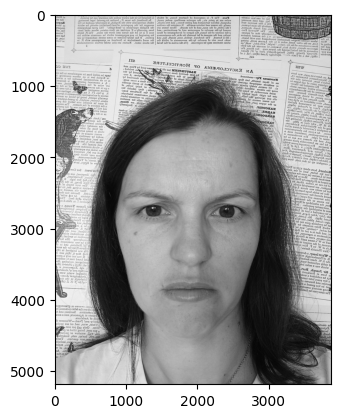

In [12]:
data = MoodDataset(aligneddir, labels)
print(len(data))
img, label = data[0]
print(img.shape)
plt.imshow(img, cmap='gray')
print(label)